In [1]:
%pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
%pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from scikeras.wrappers import KerasClassifier

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [4]:
train = "../datasets/Updated/final_train.csv"
test = "../datasets/Updated/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(np.unique(y_encoded))

print("Number of classes:", num_classes)

Number of classes: 4


In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (151470, 136, 1)
Test shape: (51569, 136, 1)


In [7]:
early_stop = EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

In [8]:
def build_cnn(filters=64,kernel_size=3,dense_units=128,dropout=0.5,lr=0.001):

    
    model = Sequential([

        Conv1D(filters,kernel_size,padding="same",activation="relu",input_shape=(X.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 2,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 4,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(dense_units, activation="relu"),

        Dropout(dropout),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
   

In [9]:
cnn_model = KerasClassifier(
    model=build_cnn,
    verbose=0
)

In [10]:
search_spaces = {
    "model__filters": Integer(32, 128),
    "model__dense_units": Integer(64, 256),
    "model__dropout": Real(0.1, 0.5),
    "model__kernel_size": Integer(3, 7),
    "model__lr": Real(1e-5, 1e-2, prior="log-uniform"),
    "batch_size": Integer(16, 64)
}

In [11]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [12]:
bayes_search = BayesSearchCV(
    estimator=cnn_model,
    search_spaces=search_spaces,
    n_iter=5,
    cv=skf,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=10,
    random_state=42
)

bayes_search.fit(X, y_encoded, callbacks=[early_stop])

print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)

Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV 1/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 1/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=0.932 total time=  32.3s
[CV 2/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 2/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=0.929 total time=  31.3s
[CV 3/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


...

[CV 9/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.934 total time=  45.4s
[CV 10/10; 1/1] START batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 10/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.931 total time=  44.5s


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best parameters: OrderedDict({'batch_size': 56, 'model__dense_units': 234, 'model__dropout': 0.22136404395367001, 'model__filters': 123, 'model__kernel_size': 6, 'model__lr': 1.537937981371367e-05})
Best CV score: 0.929722385742557


In [13]:
best_params = bayes_search.best_params_

final_model = build_cnn(
    filters=best_params["model__filters"],
    kernel_size=best_params["model__kernel_size"],
    dense_units=best_params["model__dense_units"],
    dropout=best_params["model__dropout"],
    lr=best_params["model__lr"]
)

history = final_model.fit(
    X,
    y_encoded,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4734/4734 ━━━━━━━━━━━━━━━━━━━━ 67s 14ms/step - accuracy: 0.9348 - loss: 0.1981


In [14]:
predictions = final_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_test_encoded, predicted_classes)
f1 = f1_score(y_test_encoded, predicted_classes, average="weighted")

print("\nTest Accuracy:", accuracy)
print("Test F1 Score:", f1)

1612/1612 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step

Test Accuracy: 0.9402548042428591
Test F1 Score: 0.9360272462679634


In [15]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        predicted_classes,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(y_test_encoded, predicted_classes)

print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))


Classification Report:
                   precision    recall  f1-score   support

Credential Access       1.00      1.00      1.00      8699
        Discovery       0.86      0.99      0.92     13430
   Reconnaissance       0.57      0.31      0.40      2037
             none       0.99      0.94      0.96     27403

         accuracy                           0.94     51569
        macro avg       0.85      0.81      0.82     51569
     weighted avg       0.94      0.94      0.94     51569


False Positive Rate (per class)
Credential Access: 0.0001
Discovery: 0.0581
Reconnaissance: 0.0095
none: 0.0162

Average FPR: 0.020963990736308544


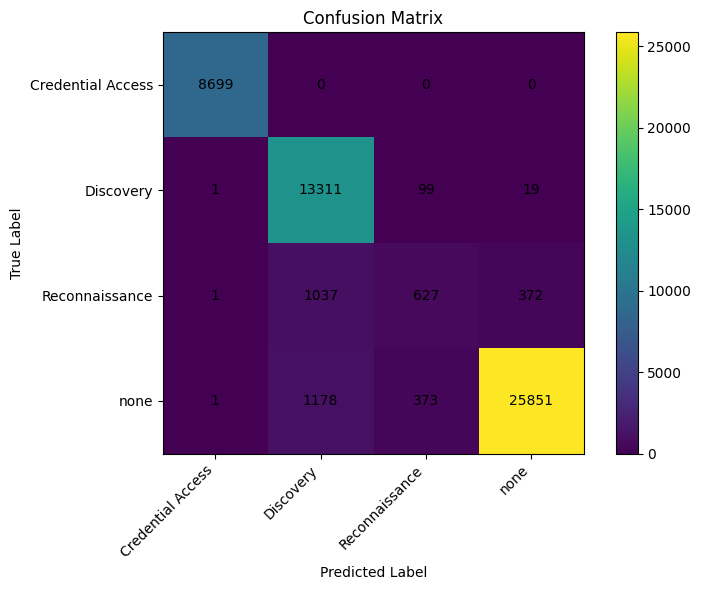

In [18]:
cm = confusion_matrix(y_test_encoded, predicted_classes)

class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

y_pred_proba = final_model.predict(X_test)

y_test_bin = label_binarize(
    y_test_encoded,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(label_encoder.classes_):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.grid(True)
plt.show()

1612/1612 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


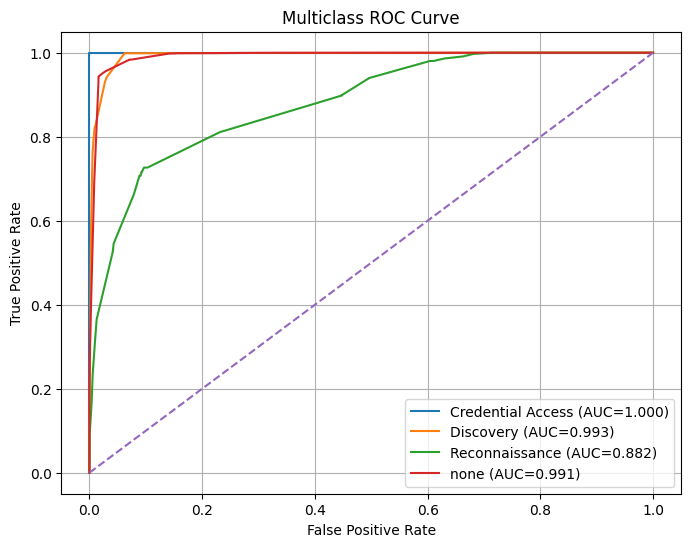

In [ ]:
plt.figure(figsize=(8, 6))

for i, label in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()